# 02 · No-Persona Similarity Analysis

Compares `NP-Think` and `NP-NoThink` no-persona conditions against the persona-conditioned pool using cosine similarity of Sentence-BERT embeddings.

In [1]:
import sys, json
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity as _cs

from src.config import FIGURES, OUTPUTS, FONT_SCALE
from src.data_loading import load_annotations, parse_demographics, create_profiles

sns.set_theme(style="whitegrid", font_scale=FONT_SCALE)
plt.rcParams["figure.dpi"] = 150

FIGURES.mkdir(exist_ok=True)
OUTPUTS.mkdir(exist_ok=True)

df = load_annotations()
df = parse_demographics(df)
df = create_profiles(df)
print(f"Persona records: {len(df):,} | Images: {df['image_id'].nunique():,}")

Persona records: 59,708 | Images: 50


## 1 · Load persona-pool embeddings

In [2]:
cap_embs  = np.load(OUTPUTS / "caption_embeddings.npy")
just_embs = np.load(OUTPUTS / "justification_embeddings.npy")
cap_ids   = pd.read_csv(OUTPUTS / "caption_embeddings_ids.csv")
# Build annotation_id → row index map
_ann2idx = {aid: i for i, aid in enumerate(cap_ids["annotation_id"].tolist())}
print(f"Caption embeddings:       {cap_embs.shape}")
print(f"Justification embeddings: {just_embs.shape}")

Caption embeddings:       (59708, 384)
Justification embeddings: (59708, 384)


## 2 · Load no-persona data and encode

In [3]:
from sentence_transformers import SentenceTransformer as _ST

NP_THINK_PATH   = Path("../data/annotations_no_persona_think.jsonl")
NP_NOTHINK_PATH = Path("../data/annotations_no_persona_no_think.jsonl")

np_think_df   = pd.DataFrame([json.loads(l) for l in NP_THINK_PATH.open()])
np_nothink_df = pd.DataFrame([json.loads(l) for l in NP_NOTHINK_PATH.open()])
print(f"NP-Think: {len(np_think_df):,}  |  NP-NoThink: {len(np_nothink_df):,}")

_model = _ST("sentence-transformers/all-MiniLM-L6-v2")

# Think condition ─────────────────────────────────────────────────────────────
NP_THINK_CAP_CACHE  = OUTPUTS / "np_caption_embeddings.npy"
NP_THINK_JUST_CACHE = OUTPUTS / "np_just_embeddings.npy"
if NP_THINK_CAP_CACHE.exists():
    np_think_cap_embs  = np.load(NP_THINK_CAP_CACHE)
    np_think_just_embs = np.load(NP_THINK_JUST_CACHE)
    print(f"Loaded NP-Think cache: {np_think_cap_embs.shape}")
else:
    np_think_cap_embs  = _model.encode(np_think_df["caption"].tolist(),
                                        normalize_embeddings=True, show_progress_bar=True)
    np_think_just_embs = _model.encode(np_think_df["justification"].tolist(),
                                        normalize_embeddings=True, show_progress_bar=True)
    np.save(NP_THINK_CAP_CACHE,  np_think_cap_embs)
    np.save(NP_THINK_JUST_CACHE, np_think_just_embs)

# NoThink condition ───────────────────────────────────────────────────────────
NP_NOTHINK_CAP_CACHE  = OUTPUTS / "np_nothink_caption_embeddings.npy"
NP_NOTHINK_JUST_CACHE = OUTPUTS / "np_nothink_just_embeddings.npy"
if NP_NOTHINK_CAP_CACHE.exists():
    np_nothink_cap_embs  = np.load(NP_NOTHINK_CAP_CACHE)
    np_nothink_just_embs = np.load(NP_NOTHINK_JUST_CACHE)
    print(f"Loaded NP-NoThink cache: {np_nothink_cap_embs.shape}")
else:
    np_nothink_cap_embs  = _model.encode(np_nothink_df["caption"].tolist(),
                                          normalize_embeddings=True, show_progress_bar=True)
    np_nothink_just_embs = _model.encode(np_nothink_df["justification"].tolist(),
                                          normalize_embeddings=True, show_progress_bar=True)
    np.save(NP_NOTHINK_CAP_CACHE,  np_nothink_cap_embs)
    np.save(NP_NOTHINK_JUST_CACHE, np_nothink_just_embs)

NP-Think: 50  |  NP-NoThink: 50


/mnt/raid5/neemias/percepta-urbana/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loaded NP-Think cache: (50, 384)
Loaded NP-NoThink cache: (50, 384)


## 3 · Compute per-image similarity to persona pool

In [4]:
sim_lookup      = pd.read_csv(OUTPUTS / "per_image_cosine_similarity.csv").set_index("image_id")["mean_sim"].to_dict()
just_sim_lookup = pd.read_csv(OUTPUTS / "per_image_just_similarity.csv").set_index("image_id")["mean_just_sim"].to_dict()

df_r = df.reset_index(drop=True)

rows = []
for img_id, group in df_r.groupby("image_id"):
    grp_ann_ids  = group["annotation_id"].tolist()
    grp_cap_idx  = [_ann2idx[a] for a in grp_ann_ids if a in _ann2idx]
    if not grp_cap_idx:
        continue
    cap_pool  = cap_embs[grp_cap_idx]
    just_pool = just_embs[grp_cap_idx]

    # find row in no-persona df
    r_think   = np_think_df[np_think_df["image_id"] == img_id]
    r_nothink = np_nothink_df[np_nothink_df["image_id"] == img_id]

    if not r_think.empty:
        i_t = r_think.index[0]
        rows.append({
            "image_id":         img_id,
            "condition":        "NP-Think",
            "np_cap_sim_mean":  float(_cs(np_think_cap_embs[[i_t]],  cap_pool)[0].mean()),
            "np_just_sim_mean": float(_cs(np_think_just_embs[[i_t]], just_pool)[0].mean()),
            "persona_cap_sim":  sim_lookup.get(img_id, float("nan")),
            "persona_just_sim": just_sim_lookup.get(img_id, float("nan")),
        })

    if not r_nothink.empty:
        i_n = r_nothink.index[0]
        rows.append({
            "image_id":         img_id,
            "condition":        "NP-NoThink",
            "np_cap_sim_mean":  float(_cs(np_nothink_cap_embs[[i_n]],  cap_pool)[0].mean()),
            "np_just_sim_mean": float(_cs(np_nothink_just_embs[[i_n]], just_pool)[0].mean()),
            "persona_cap_sim":  sim_lookup.get(img_id, float("nan")),
            "persona_just_sim": just_sim_lookup.get(img_id, float("nan")),
        })

np_comp_df = pd.DataFrame(rows)
np_comp_df.to_csv(OUTPUTS / "no_persona_text_similarity.csv", index=False)
print(np_comp_df.groupby("condition")[["np_cap_sim_mean", "np_just_sim_mean",
                                        "persona_cap_sim", "persona_just_sim"]].mean().round(4))

            np_cap_sim_mean  np_just_sim_mean  persona_cap_sim  \
condition                                                        
NP-NoThink           0.8619            0.5389           0.8727   
NP-Think             0.8648            0.5496           0.8727   

            persona_just_sim  
condition                     
NP-NoThink            0.5639  
NP-Think              0.5639  


## 4 · Figure — no-persona vs. persona pool similarity

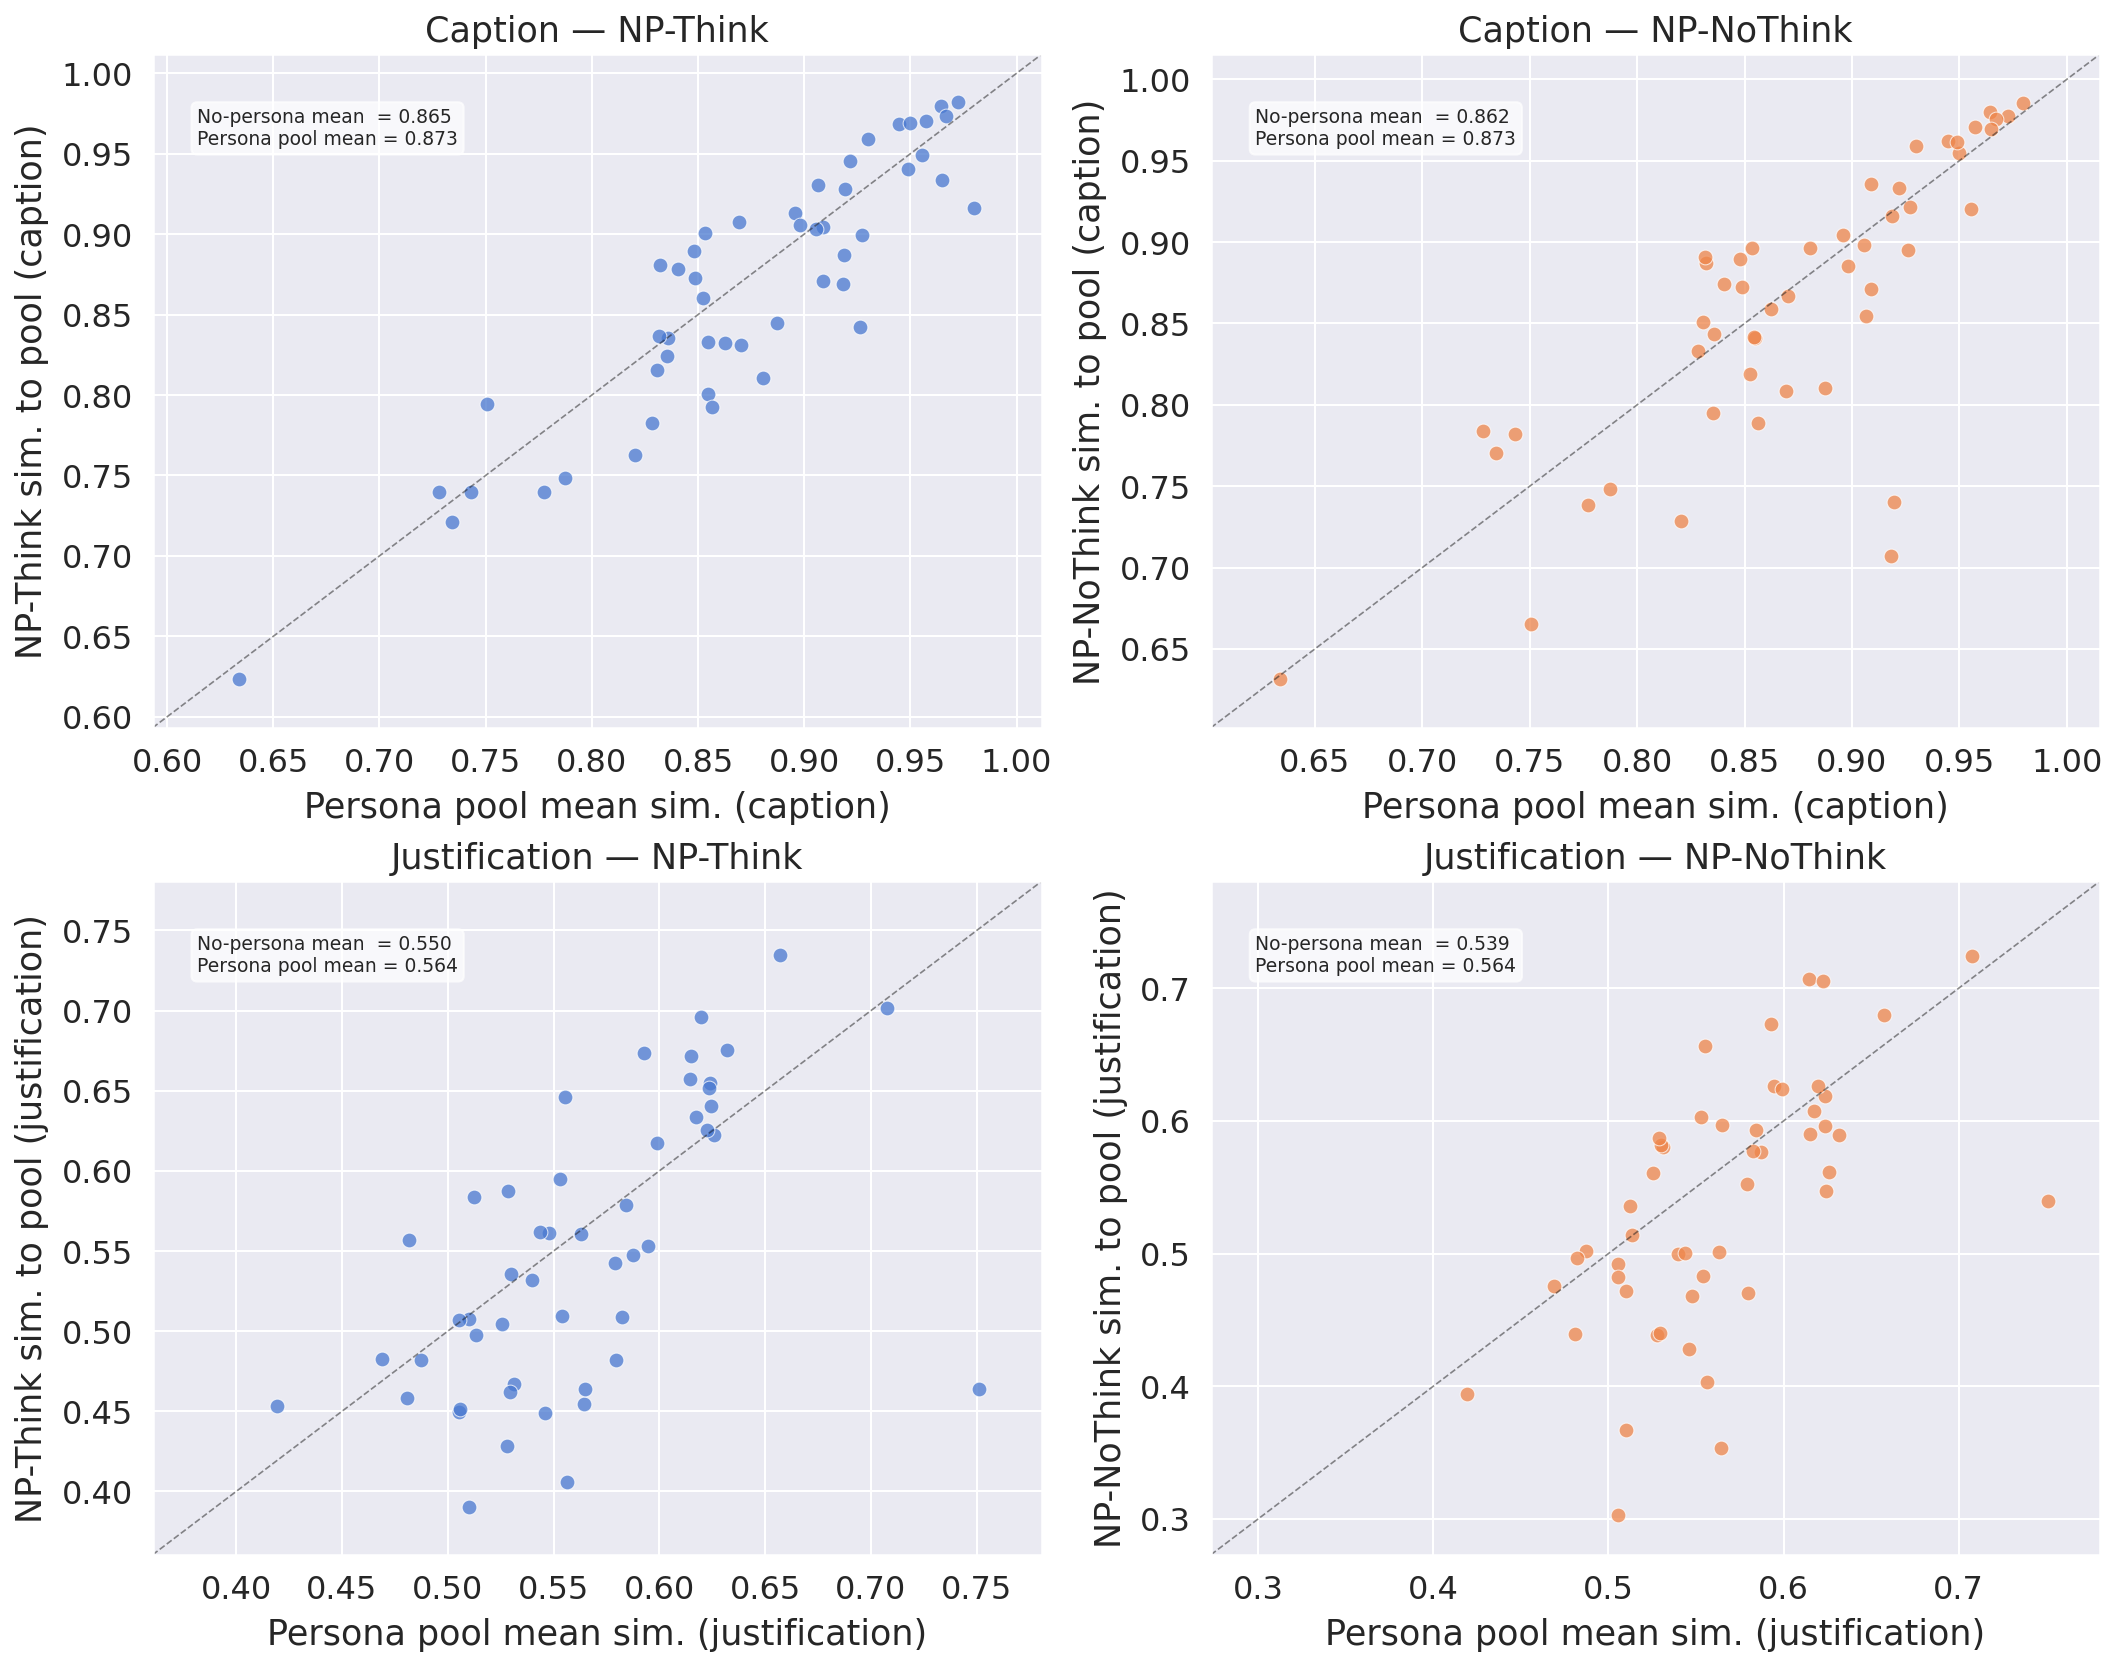

Saved fig_no_persona_text_similarity


In [5]:
sns.set_theme(font_scale=1.4)
MUTED = sns.color_palette("muted")

conditions = ["NP-Think", "NP-NoThink"]
modalities = [
    ("np_cap_sim_mean",  "persona_cap_sim",  "Caption"),
    ("np_just_sim_mean", "persona_just_sim", "Justification"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 11), constrained_layout=True)

for row_i, (np_col, pers_col, mod_title) in enumerate(modalities):
    for col_i, cond in enumerate(conditions):
        ax = axes[row_i][col_i]
        sub = np_comp_df[np_comp_df["condition"] == cond]

        ax.scatter(sub[pers_col], sub[np_col],
                   alpha=0.75, s=50, color=MUTED[col_i],
                   edgecolors="white", linewidths=0.5)
        lims = [
            min(sub[pers_col].min(), sub[np_col].min()) - 0.03,
            max(sub[pers_col].max(), sub[np_col].max()) + 0.03,
        ]
        ax.plot(lims, lims, "k--", linewidth=0.8, alpha=0.5)
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel(f"Persona pool mean sim. ({mod_title.lower()})", labelpad=6)
        ax.set_ylabel(f"{cond} sim. to pool ({mod_title.lower()})", labelpad=6)
        ax.set_title(f"{mod_title} — {cond}")
        np_mean   = sub[np_col].mean()
        pers_mean = sub[pers_col].mean()
        ax.text(0.05, 0.92,
                f"No-persona mean  = {np_mean:.3f}\nPersona pool mean = {pers_mean:.3f}",
                transform=ax.transAxes, fontsize=9, va="top",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

fig.savefig(FIGURES / "fig_no_persona_text_similarity.pdf", bbox_inches="tight")
fig.savefig(FIGURES / "fig_no_persona_text_similarity.png", bbox_inches="tight")
plt.show()
print("Saved fig_no_persona_text_similarity")